# Principled data-query overview

Row set = every mouse with **at least 3 sessions** in the *new* QC-passed pool
(`bwm_qc_new_08-03-2026`, 340 sessions, from `alternative_sessions_query_qc.py`).

On a per-mouse session heatmap (same protocol colouring as `data_query_overview.ipynb`),
for those mice we highlight three things:

| border | meaning |
|---|---|
| **black** | session is in the new 340 QC pool |
| **red** | LightningPose available on ONE, **not** in the pool, and **passes** the video-QC criteria |
| **grey dashed** | LightningPose available on ONE, **not** in the pool, and **fails** the video-QC criteria |

The video-QC criteria are the exact 14-clause left+right lightningPose/video filter used in
`alternative_sessions_query_qc.py`.

The per-mouse session cache (`all_session_details_bwm`) is refreshed on the fly for any
qualifying mouse whose pool/LP sessions post-date it (the 7 CSHL mice past the aggregate cutoff).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from datetime import datetime

from one.api import ONE
from segmentation_functions import extended_qc

prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

repo = prefix + 'representation_learning_variability/'
data_query_path = repo + 'paper-individuality/segmentation/data_query/'
video_qc_path = repo + 'Video and wheel/Video QC/'

sessions_cache = video_qc_path + 'all_session_details_bwm'          # per-mouse session list
new_pool_file  = data_query_path + 'bwm_qc_new_08-03-2026'          # the 340 pool
lp_cache       = data_query_path + 'lp_by_subject_principled.npy'   # per-subject LP availability
lp_qc_cache    = data_query_path + 'extra_lp_video_qc_principled'   # candidate-LP extended_qc
star_qc_cache   = data_query_path + 'star_crucial_qc_principled.pkl' # crucial video-QC for target/backward sessions

MIN_SESSIONS  = 3       # sessions-per-mouse threshold defining the row set
USE_CACHED_LP = True    # per-subject LP availability query is slow -> cache it
USE_CACHED_QC = True    # candidate-LP extended_qc is slow -> cache it

one = ONE(base_url='https://alyx.internationalbrainlab.org', silent=True)

In [2]:
# ---------------------------------------------------------------------------
# 1. Per-mouse session table + protocol colour code (same as the overview nb)
# ---------------------------------------------------------------------------
all_sessions = pd.read_csv(sessions_cache, compression='gzip').drop(
    columns=['Unnamed: 0'], errors='ignore')
cache_date = datetime.fromtimestamp(os.path.getmtime(sessions_cache)).date()
print(f'Loaded session table: {len(all_sessions)} rows, '
      f'{all_sessions["subject"].nunique()} mice (cache dated {cache_date}).')

# Same categorical palette as data_check.ipynb / data_query_overview.ipynb
colors = ['#add8ff', '#ffd8a8', '#a8ffb0']  # training / biased / ephys
purple_start, purple_end = to_rgb('#d8b0ff'), to_rgb('#4b0082')
for i in range(4):
    t = i / 3
    colors.append(tuple(s + t * (e - s) for s, e in zip(purple_start, purple_end)))
colors.append('#ff9999')  # unbiasable
colors.append('#990000')  # untrainable
cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5], cmap.N)


def add_protocol_number(df):
    df = df.copy()
    df['protocol_number'] = np.nan
    df.loc[df['task_protocol'].str.contains('training', na=False), 'protocol_number'] = 0
    df.loc[df['task_protocol'].str.contains('biased', na=False), 'protocol_number'] = 1
    df.loc[df['task_protocol'].str.contains('ephys', na=False), 'protocol_number'] = 2
    df['training_status'] = df['training_status'].astype(str)
    df.loc[df['training_status'].str.contains('trained 1b'), 'protocol_number'] = 3
    df.loc[df['training_status'].str.contains('ready4ephysrig'), 'protocol_number'] = 4
    df.loc[df['training_status'].str.contains('ready4delay'), 'protocol_number'] = 5
    df.loc[df['training_status'].str.contains('ready4recording'), 'protocol_number'] = 6
    df.loc[df['training_status'].str.contains('unbiasable'), 'protocol_number'] = 7
    df.loc[df['training_status'].str.contains('untrainable'), 'protocol_number'] = 8
    return df

Loaded session table: 8733 rows, 142 mice (cache dated 2026-03-12).


In [3]:
# ---------------------------------------------------------------------------
# 2. Load the 340 pool and find mice with >= MIN_SESSIONS sessions in it
# ---------------------------------------------------------------------------
new_pool = pd.read_pickle(new_pool_file, compression='gzip')
new_eids = list(dict.fromkeys(new_pool['eid']))
print(f'{len(new_eids)} sessions in the new pool.')

cache_subj = all_sessions.drop_duplicates('session').set_index('session')['subject']
eid2subj = {}
for eid in new_eids:
    if eid in cache_subj.index:
        eid2subj[eid] = cache_subj.loc[eid]
    else:
        try:
            eid2subj[eid] = one.get_details(eid)['subject']
        except Exception as err:
            print('could not resolve subject for', eid, err)

pool_counts = pd.Series(list(eid2subj.values())).value_counts()
qualifying_subjects = sorted(pool_counts[pool_counts >= MIN_SESSIONS].index)
print(f'{len(qualifying_subjects)} mice have >= {MIN_SESSIONS} sessions in the new pool.')

pool_eids_by_subject = {s: [] for s in qualifying_subjects}
for eid, subj in eid2subj.items():
    if subj in pool_eids_by_subject:
        pool_eids_by_subject[subj].append(eid)

340 sessions in the new pool.


58 mice have >= 3 sessions in the new pool.


In [4]:
# ---------------------------------------------------------------------------
# 3. LightningPose availability on ONE for the qualifying mice
#    dataset_type='camera.lightningPose' covers left/right/body views at once
# ---------------------------------------------------------------------------
if USE_CACHED_LP and os.path.exists(lp_cache):
    lp_by_subject = {s: set(v) for s, v in np.load(lp_cache, allow_pickle=True).item().items()}
    to_query = [s for s in qualifying_subjects if s not in lp_by_subject]
else:
    lp_by_subject, to_query = {}, list(qualifying_subjects)

for subj in to_query:
    try:
        ds = one.alyx.rest('datasets', 'list', dataset_type='camera.lightningPose', subject=subj)
        lp_by_subject[subj] = {d['session'].rstrip('/').split('/')[-1] for d in ds}
    except Exception as err:
        print(subj, 'LP query error:', err)
        lp_by_subject[subj] = set()

if to_query or not os.path.exists(lp_cache):
    np.save(lp_cache, {s: list(v) for s, v in lp_by_subject.items()})

n_lp_total = sum(len(lp_by_subject.get(s, set())) for s in qualifying_subjects)
print(f'{n_lp_total} LightningPose sessions on ONE across the {len(qualifying_subjects)} qualifying mice.')

416 LightningPose sessions on ONE across the 58 qualifying mice.


In [5]:
# ---------------------------------------------------------------------------
# 4. Self-heal the session table so every pool/LP session of a qualifying mouse
#    can be placed on the grid.
#
#    The cached table (and the per-mouse _ibl_subjectTrials aggregate it is built
#    from) is INCOMPLETE for 7 CSHL mice: their late-Feb-2020 ephys sessions
#    post-date the aggregate's last entry, so re-fetching the aggregate does not
#    recover them. Instead we patch any missing pool/LP session directly from
#    one.get_details (date + protocol) and renumber each mouse chronologically.
# ---------------------------------------------------------------------------
all_sessions['session_start_time'] = pd.to_datetime(
    all_sessions['session_start_time'], errors='coerce', utc=True)

rows_by_subject = {s: set(all_sessions.loc[all_sessions['subject'] == s, 'session'])
                   for s in qualifying_subjects}
patch_rows = []
for s in qualifying_subjects:
    want = set(pool_eids_by_subject[s]) | set(lp_by_subject.get(s, set()))
    for eid in want - rows_by_subject[s]:
        try:
            d = one.get_details(eid)
            patch_rows.append({'subject': s, 'session': eid,
                               'session_start_time': pd.to_datetime(d['start_time'], utc=True),
                               'task_protocol': d.get('task_protocol'),
                               'training_status': np.nan})
        except Exception as err:
            print('patch failed', eid, err)
print(f'{len(patch_rows)} missing pool/LP sessions patched via get_details.')
if patch_rows:
    all_sessions = pd.concat([all_sessions, pd.DataFrame(patch_rows)], ignore_index=True)

# Renumber every qualifying mouse chronologically so patched rows get a slot
for s in qualifying_subjects:
    idx = all_sessions.index[all_sessions['subject'] == s]
    order = all_sessions.loc[idx].sort_values('session_start_time').index
    all_sessions.loc[order, 'session_number'] = np.arange(len(order))

all_sessions = add_protocol_number(all_sessions)
lookup = all_sessions.drop_duplicates('session').set_index('session')[['subject', 'session_number']]

still_missing = [e for s in qualifying_subjects
                 for e in (set(pool_eids_by_subject[s]) | set(lp_by_subject.get(s, set())))
                 if e not in lookup.index]
print(f'{len(still_missing)} pool/LP sessions still unplaceable after patch.')

29 missing pool/LP sessions patched via get_details.
0 pool/LP sessions still unplaceable after patch.


In [6]:
# ---------------------------------------------------------------------------
# 5. Video-QC verdict for the candidate LP sessions (LP available, not in pool)
#    Protocol-aware: training/biased sessions run on the single-camera (left-only)
#    rig, so we apply only the LEFT-camera clauses to them; the RIGHT-camera
#    clauses are required for ephys sessions only. (ephys is the only two-camera
#    protocol -- requiring right-camera QC on biased/training always fails them.)
# ---------------------------------------------------------------------------
candidate_eids = sorted({e for s in qualifying_subjects
                         for e in lp_by_subject.get(s, set())
                         if e not in set(pool_eids_by_subject[s])})
print(f'{len(candidate_eids)} candidate LP-not-in-pool sessions.')

# protocol per session (from the patched session table)
proto_of = all_sessions.drop_duplicates('session').set_index('session')['task_protocol']
def _is_ephys(eid):
    p = proto_of.get(eid, '')
    return isinstance(p, str) and 'ephys' in p

# gather extended_qc for candidates, caching to disk
if USE_CACHED_QC and os.path.exists(lp_qc_cache):
    qc_df = pd.read_pickle(lp_qc_cache, compression='gzip')
else:
    qc_df = pd.DataFrame(columns=['eid'])
have = set(qc_df['eid']) if len(qc_df) else set()
missing_qc = [e for e in candidate_eids if e not in have]
print(f'{len(missing_qc)} candidates need a fresh extended_qc query.')
if missing_qc:
    fresh_qc = extended_qc(one, missing_qc)
    qc_df = pd.concat([qc_df, fresh_qc], ignore_index=True)
    qc_df.to_pickle(lp_qc_cache, compression='gzip')

# QC entries come in two formats depending on the QC version that wrote them:
#   boolean-first  [True, 0]        (recording-rig / ephys sessions)
#   string-first   ['PASS', 1, 0]   (training-rig / biased sessions)
# The verdict is the FIRST element. The original alternative_sessions_query_qc.py
# used `True in x`, which silently misreads the string-first format (it only
# matched when a stray 1 happened to be in the list) -- so biased sessions were
# wrongly failed. Parse the first element instead.
def _verdict_ok(x, allow_none=False):
    if isinstance(x, list):
        return len(x) > 0 and (x[0] is True or x[0] == 'PASS')
    if allow_none and x is None:
        return True
    return x is True or x == 'PASS'

def _lt(x):  return _verdict_ok(x)
def _ltn(x): return _verdict_ok(x, allow_none=True)

def _camera_pass(e, side):
    e = e.copy()
    cols = [f'_lightningPose{side}_lick_detection', f'_lightningPose{side}_time_trace_length_match',
            f'_video{side}_pin_state', f'_lightningPose{side}_trace_all_nan',
            f'_video{side}_camera_times', f'_video{side}_dropped_frames', f'_video{side}_timestamps']
    for c in cols:
        if c not in e.columns:
            e[c] = np.nan
    mask = (e[f'_lightningPose{side}_lick_detection'].isin(['PASS']) &
            e[f'_lightningPose{side}_time_trace_length_match'].isin(['PASS']) &
            e[f'_video{side}_pin_state'].apply(_lt) &
            e[f'_lightningPose{side}_trace_all_nan'].isin(['PASS']) &
            e[f'_video{side}_camera_times'].apply(_lt) &
            e[f'_video{side}_dropped_frames'].apply(_ltn) &
            e[f'_video{side}_timestamps'].isin([True, 'PASS']))
    return pd.Series(mask.values, index=e['eid'].values)

left_pass = _camera_pass(qc_df, 'Left')
right_pass = _camera_pass(qc_df, 'Right')

# ephys -> need both cameras; biased/training -> left camera only
candidate_pass = set()
for e in candidate_eids:
    ok = bool(left_pass.get(e, False))
    if _is_ephys(e):
        ok = ok and bool(right_pass.get(e, False))
    if ok:
        candidate_pass.add(e)
candidate_fail = set(candidate_eids) - candidate_pass
n_ephys_cand = sum(_is_ephys(e) for e in candidate_eids)
print(f'candidate LP sessions: {len(candidate_pass)} PASS video-QC, {len(candidate_fail)} FAIL '
      f'({n_ephys_cand} ephys use both cameras, {len(candidate_eids) - n_ephys_cand} biased/training use left only)')

143 candidate LP-not-in-pool sessions.
0 candidates need a fresh extended_qc query.
candidate LP sessions: 69 PASS video-QC, 74 FAIL (43 ephys use both cameras, 100 biased/training use left only)


In [7]:
# ---------------------------------------------------------------------------
# 6. LP-processing TARGET sessions (candidates to send for LightningPose)
#    Two behavioural timepoints per mouse:
#      (A) last training-protocol session         -> transition INTO biased
#      (B) biased-protocol session at/after the first ready4ephysrig status
#          -> a biased timepoint that REUSES already-computed LP data
# ---------------------------------------------------------------------------
alls_q = all_sessions[all_sessions['subject'].isin(qualifying_subjects)].copy()
alls_q['session_start_time'] = pd.to_datetime(alls_q['session_start_time'], errors='coerce', utc=True)

# (A) last training session per mouse
last_training = {}
for s in qualifying_subjects:
    tr = alls_q[(alls_q['subject'] == s) & alls_q['task_protocol'].str.contains('training', na=False)]
    if len(tr):
        last_training[s] = tr.sort_values('session_start_time')['session'].iloc[-1]
last_training_eids = set(last_training.values())
print(f'(A) {len(last_training_eids)} last-training sessions (one per mouse).')

# (B) REUSE strategy: per mouse, the LATEST biased-protocol session that ALREADY
#     has LightningPose, dated before the mouse's first ephys session. This reuses
#     already-computed LP -- no new processing. video-QC pass/fail comes straight
#     from candidate_pass (the left-only-for-biased verdict computed above).
reuse_biased = {}
for s in qualifying_subjects:
    sub = alls_q[alls_q['subject'] == s].sort_values('session_start_time')
    lp_s = lp_by_subject.get(s, set())
    ephys = sub[sub['task_protocol'].str.contains('ephys', na=False)]
    first_ephys = ephys['session_start_time'].min() if len(ephys) else pd.Timestamp.max.tz_localize('UTC')
    bwl = sub[(sub['task_protocol'].str.contains('biased', na=False)) &
              (sub['session'].isin(lp_s)) & (sub['session_start_time'] < first_ephys)]
    if len(bwl):
        reuse_biased[s] = bwl['session'].iloc[-1]
reuse_pass = {s: e for s, e in reuse_biased.items() if e in candidate_pass}
reuse_fail = {s: e for s, e in reuse_biased.items() if e not in candidate_pass}
uncovered = [s for s in qualifying_subjects if s not in reuse_biased]
print(f'(B) reuse tier: {len(reuse_biased)}/{len(qualifying_subjects)} mice have an existing-LP '
      f'biased session pre-ephys ({len(reuse_pass)} pass video-QC = reuse-ready, '
      f'{len(reuse_fail)} fail = reprocess); {len(uncovered)} mice need a NEW biased LP job.')

# (C) SEND-FOR-LP target: for each uncovered mouse, the LATEST biased session
#     before first ephys that does NOT yet have LP -> the session to process.
send_lp_biased, no_biased_pre = {}, []
for s in uncovered:
    sub = alls_q[alls_q['subject'] == s].sort_values('session_start_time')
    ephys = sub[sub['task_protocol'].str.contains('ephys', na=False)]
    first_ephys = ephys['session_start_time'].min() if len(ephys) else pd.Timestamp.max.tz_localize('UTC')
    bpre = sub[(sub['task_protocol'].str.contains('biased', na=False)) &
               (sub['session_start_time'] < first_ephys)]
    if len(bpre):
        send_lp_biased[s] = bpre['session'].iloc[-1]
    else:
        no_biased_pre.append(s)
print(f'(C) {len(send_lp_biased)}/{len(uncovered)} uncovered mice have a biased pre-ephys session '
      f'to send for LP ({len(no_biased_pre)} have none: {no_biased_pre}).')

(A) 58 last-training sessions (one per mouse).
(B) reuse tier: 24/58 mice have an existing-LP biased session pre-ephys (11 pass video-QC = reuse-ready, 13 fail = reprocess); 34 mice need a NEW biased LP job.


(C) 34/34 uncovered mice have a biased pre-ephys session to send for LP (0 have none: []).


In [8]:
# ---------------------------------------------------------------------------
# 7. QC-check the target ("star") sessions; for those that EXPLICITLY fail a
#    crucial left-camera video metric, fall back to the nearest earlier
#    same-protocol session that passes all of them.
#    Crucial (LP-relevant, available pre-LP): pin_state, camera_times,
#    dropped_frames, timestamps (left camera). Sessions with NO video QC yet
#    are left as-is (they'll be QC'd when LP runs), not substituted.
# ---------------------------------------------------------------------------
CRUCIAL = ['_videoLeft_pin_state', '_videoLeft_camera_times',
           '_videoLeft_dropped_frames', '_videoLeft_timestamps']

_qc_cache = pd.read_pickle(star_qc_cache) if os.path.exists(star_qc_cache) else {}
def crucial_qc(eid):
    if eid not in _qc_cache:
        try:
            x = one.get_details(eid, True)['extended_qc'] or {}
        except Exception:
            x = {}
        _qc_cache[eid] = {c: x.get(c) for c in CRUCIAL}
    return _qc_cache[eid]

def _computed(v):
    return not ((isinstance(v, float) and pd.isna(v)) or
                (isinstance(v, list) and len(v) and v[0] == 'NOT_SET'))
def _meets_crucial(q):
    return all(_computed(q.get(c)) and _verdict_ok(q.get(c), allow_none=c.endswith('dropped_frames'))
               for c in CRUCIAL)
def _explicit_fail(q):
    return any(_computed(q.get(c)) and not _verdict_ok(q.get(c), allow_none=c.endswith('dropped_frames'))
               for c in CRUCIAL)

star_targets = {**{e: ('last_training', s) for s, e in last_training.items()},
                **{e: ('send_biased', s) for s, e in send_lp_biased.items()}}
date_of = all_sessions.drop_duplicates('session').set_index('session')['session_start_time']

replacements = {}
n_meets = n_fail = n_none = 0
for star, (typ, s) in star_targets.items():
    q = crucial_qc(star)
    if _meets_crucial(q):
        n_meets += 1; continue
    if not _explicit_fail(q):
        n_none += 1; continue                      # no video QC yet -> keep star as-is
    n_fail += 1
    proto = 'training' if typ == 'last_training' else 'biased'
    d = date_of.get(star)
    earlier = all_sessions[(all_sessions['subject'] == s) &
                           all_sessions['task_protocol'].str.contains(proto, na=False) &
                           (all_sessions['session_start_time'] < d)].sort_values(
                               'session_start_time', ascending=False)
    for _, c in earlier.head(25).iterrows():
        if _meets_crucial(crucial_qc(c['session'])):
            replacements[star] = c['session']; break

pd.to_pickle(_qc_cache, star_qc_cache)
print(f'star QC: {n_meets} meet crucial video-QC, {n_fail} explicitly FAIL, '
      f'{n_none} have no video QC computed (kept as-is).')
print(f'backward fallback: {len(replacements)}/{n_fail} failing stars matched to an earlier passing session.')

star QC: 21 meet crucial video-QC, 19 explicitly FAIL, 52 have no video QC computed (kept as-is).
backward fallback: 7/19 failing stars matched to an earlier passing session.


273 pool cells (black); 69 LP-pass (red); 74 LP-fail (grey); reuse biased: 11 ready (blue solid) + 13 reprocess (blue dashed); 34 biased send-for-LP (blue star); 58 last-training targets (magenta star); 7 QC fallbacks (lime P).


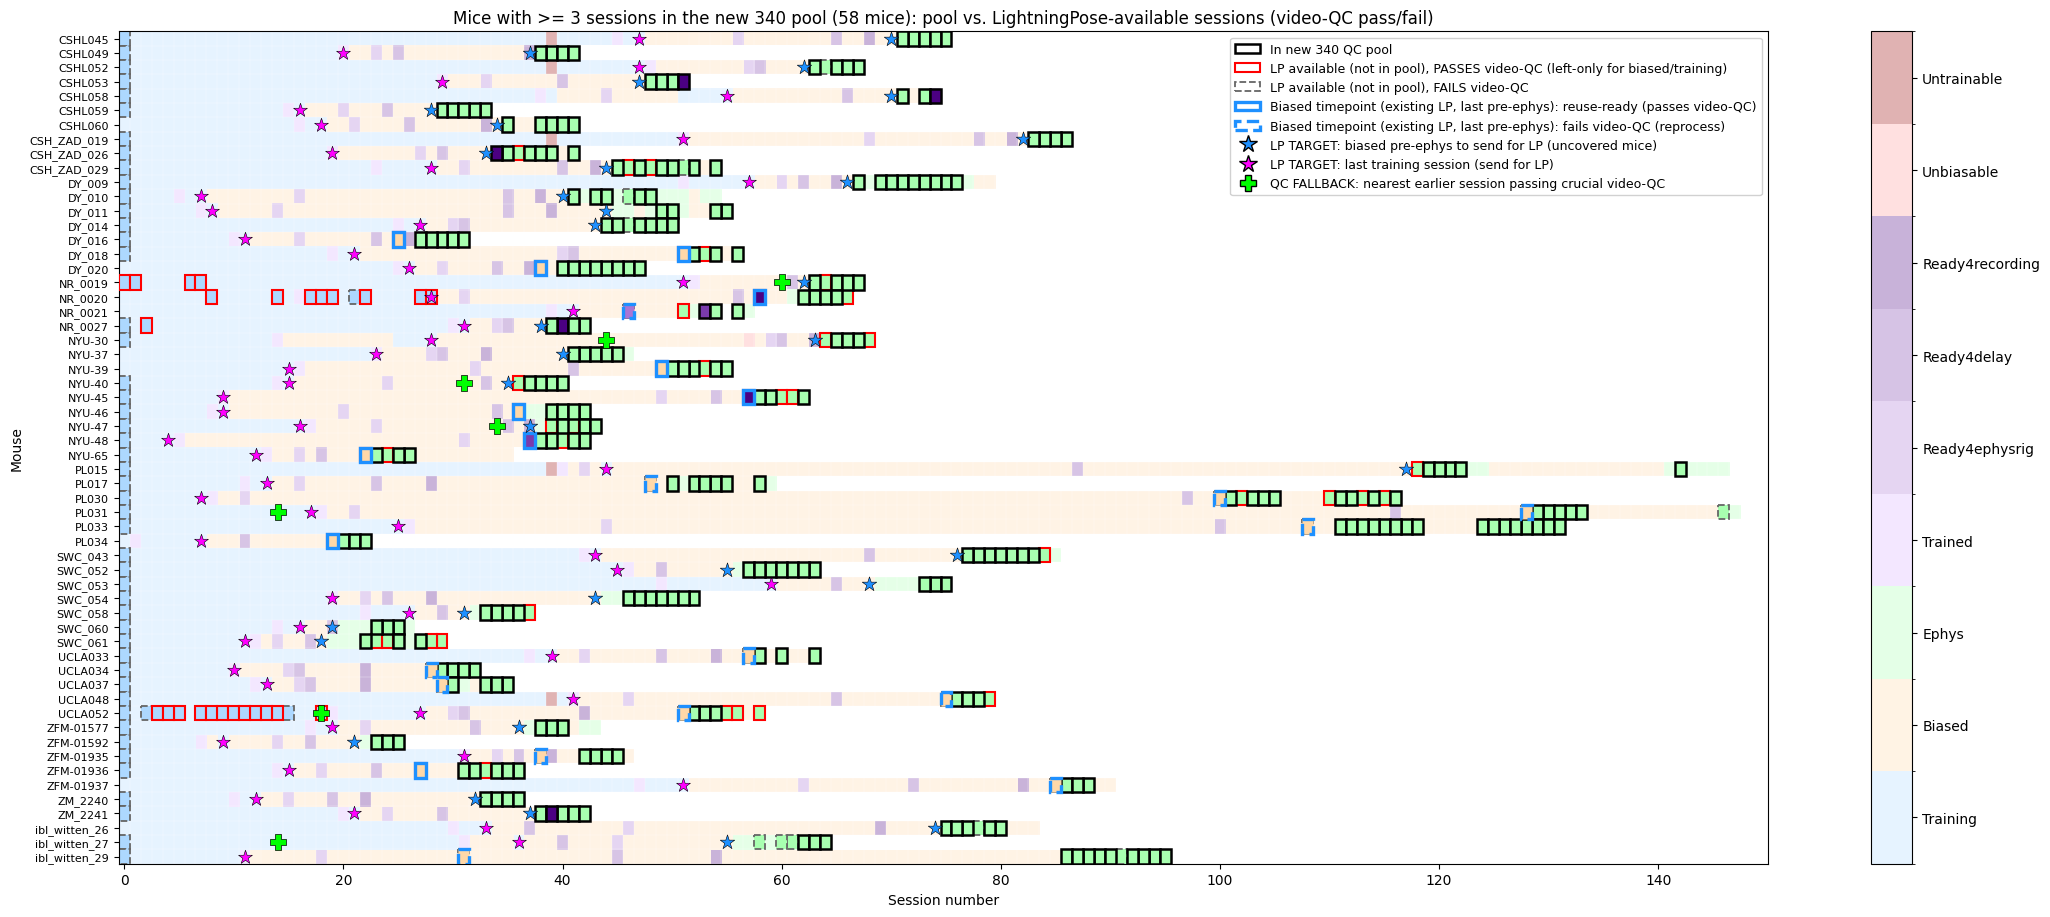

In [9]:
# ---------------------------------------------------------------------------
# 8. Plot
# ---------------------------------------------------------------------------
row_of = {s: i for i, s in enumerate(qualifying_subjects)}
n_rows = len(qualifying_subjects)
max_sn = int(all_sessions.loc[all_sessions['subject'].isin(qualifying_subjects),
                              'session_number'].max()) + 1

protocol_matrix = np.full((n_rows, max_sn), np.nan)
for s in qualifying_subjects:
    sub_df = all_sessions[all_sessions['subject'] == s]
    protocol_matrix[row_of[s], sub_df['session_number'].astype(int)] = sub_df['protocol_number']

fig, ax = plt.subplots(figsize=(22, 0.16 * n_rows))
ax.imshow(protocol_matrix, aspect='auto', cmap=cmap, norm=norm, alpha=0.30)  # dim background
ax.set_xlabel('Session number'); ax.set_ylabel('Mouse')
ax.set_yticks(np.arange(n_rows)); ax.set_yticklabels(qualifying_subjects, fontsize=8)
ax.set_xticks(np.arange(-0.5, max_sn, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=0.2)
ax.tick_params(which='minor', length=0)


def cell_number(subj, eid):
    m = all_sessions.loc[(all_sessions['subject'] == subj) & (all_sessions['session'] == eid),
                         'session_number']
    return None if m.empty else int(m.iloc[0])


def paint(subj, eid, edgecolor, lw, zorder, linestyle='-'):
    row_i = row_of[subj]
    sn = cell_number(subj, eid)
    if sn is None or sn >= max_sn or np.isnan(protocol_matrix[row_i, sn]):
        return 0
    ax.add_patch(Rectangle((sn - 0.5, row_i - 0.5), 1, 1, fill=True,
                           facecolor=cmap(norm(protocol_matrix[row_i, sn])), alpha=1.0,
                           edgecolor=edgecolor, linewidth=lw, linestyle=linestyle, zorder=zorder))
    return 1


n_pool = n_pass = n_fail = n_biased_tgt = 0
for subj in qualifying_subjects:
    pool_set = set(pool_eids_by_subject[subj])
    lp_set = lp_by_subject.get(subj, set())
    # LP fails video-QC (grey dashed) -- drawn first
    for eid in (lp_set - pool_set) & candidate_fail:
        n_fail += paint(subj, eid, '0.4', 1.3, 2.5, linestyle='--')
    # LP passes video-QC (red)
    for eid in (lp_set - pool_set) & candidate_pass:
        n_pass += paint(subj, eid, 'red', 1.5, 2.7)
    # in the 340 pool (black)
    for eid in pool_set:
        n_pool += paint(subj, eid, 'black', 1.8, 3.0)

# (B) REUSE biased timepoint: blue outline on top (solid=reuse-ready, dashed=reprocess)
n_reuse_pass = n_reuse_fail = 0
for subj, eid in reuse_pass.items():
    n_reuse_pass += paint(subj, eid, 'dodgerblue', 2.4, 3.2)
for subj, eid in reuse_fail.items():
    n_reuse_fail += paint(subj, eid, 'dodgerblue', 2.4, 3.2, linestyle='--')

# (C) SEND-FOR-LP biased target -> blue star marker
n_send = 0
for subj, eid in send_lp_biased.items():
    sn = cell_number(subj, eid)
    if sn is None or sn >= max_sn or np.isnan(protocol_matrix[row_of[subj], sn]):
        continue
    ax.scatter(sn, row_of[subj], marker='*', s=120, facecolor='dodgerblue',
               edgecolor='black', linewidth=0.4, zorder=4)
    n_send += 1

# (A) last-training LP TARGET -> magenta star marker on top of everything
n_last_tgt = 0
for subj, eid in last_training.items():
    sn = cell_number(subj, eid)
    if sn is None or sn >= max_sn or np.isnan(protocol_matrix[row_of[subj], sn]):
        continue
    ax.scatter(sn, row_of[subj], marker='*', s=110, facecolor='magenta',
               edgecolor='black', linewidth=0.4, zorder=4)
    n_last_tgt += 1

# Fallback: nearest earlier passing session for stars that failed crucial video-QC
n_repl = 0
for star, repl in replacements.items():
    _, s = star_targets[star]
    sn = cell_number(s, repl)
    if sn is None or sn >= max_sn or np.isnan(protocol_matrix[row_of[s], sn]):
        continue
    ax.scatter(sn, row_of[s], marker='P', s=130, facecolor='lime',
               edgecolor='black', linewidth=0.5, zorder=4.5)
    n_repl += 1

print(f'{n_pool} pool cells (black); {n_pass} LP-pass (red); {n_fail} LP-fail (grey); '
      f'reuse biased: {n_reuse_pass} ready (blue solid) + {n_reuse_fail} reprocess (blue dashed); '
      f'{n_send} biased send-for-LP (blue star); {n_last_tgt} last-training targets (magenta star); '
      f'{n_repl} QC fallbacks (lime P).')

handles = [
    Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='black', linewidth=1.8,
              label='In new 340 QC pool'),
    Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='red', linewidth=1.5,
              label='LP available (not in pool), PASSES video-QC (left-only for biased/training)'),
    Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='0.4', linewidth=1.3, linestyle='--',
              label='LP available (not in pool), FAILS video-QC'),
    Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='dodgerblue', linewidth=2.4,
              label='Biased timepoint (existing LP, last pre-ephys): reuse-ready (passes video-QC)'),
    Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='dodgerblue', linewidth=2.4, linestyle='--',
              label='Biased timepoint (existing LP, last pre-ephys): fails video-QC (reprocess)'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='dodgerblue',
           markeredgecolor='black', markersize=13, label='LP TARGET: biased pre-ephys to send for LP (uncovered mice)'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='magenta',
           markeredgecolor='black', markersize=13, label='LP TARGET: last training session (send for LP)'),
    Line2D([0], [0], marker='P', color='none', markerfacecolor='lime',
           markeredgecolor='black', markersize=12, label='QC FALLBACK: nearest earlier session passing crucial video-QC'),
]
ax.legend(handles=handles, loc='upper right', framealpha=0.9, fontsize=9)

cbar = plt.colorbar(ax.images[0], ax=ax, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
cbar.ax.set_yticklabels(['Training', 'Biased', 'Ephys', 'Trained', 'Ready4ephysrig',
                         'Ready4delay', 'Ready4recording', 'Unbiasable', 'Untrainable'])
ax.set_title(f'Mice with >= {MIN_SESSIONS} sessions in the new 340 pool ({n_rows} mice): '
             f'pool vs. LightningPose-available sessions (video-QC pass/fail)')
plt.xlim([-.5, 150]); plt.tight_layout()
plt.savefig(data_query_path + 'data_query_overview_principled.png', dpi=150, bbox_inches='tight')
plt.show()